In [24]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

In [25]:
file = Path("../data/repeated_10_scale_250/100206_repeated10_scale250.graphml")

G = nx.read_graphml(file)

print("Graph loaded.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph loaded.
Nodes: 463
Edges: 5863


In [26]:
node_num_cols = [
    "dn_position_x", "dn_position_y", "dn_position_z", "dn_correspondence_id"
]

edge_num_cols = [
    "fiber_length_mean", "FA_mean", "number_of_fibers"
]


# Nodes
node_records = []
for node_id, attrs in G.nodes(data=True):
    node_records.append({
        "file": file.name,
        "path": str(file),
        "node_id": node_id,
        **attrs
    })

nodes_df = pd.DataFrame(node_records)

for col in node_num_cols:
    if col in nodes_df.columns:
        nodes_df[col] = pd.to_numeric(nodes_df[col], errors="coerce")


# Edges
edge_records = []
for u, v, attrs in G.edges(data=True):
    edge_records.append({
        "file": file.name,
        "path": str(file),
        "source": u,
        "target": v,
        **attrs
    })

edges_df = pd.DataFrame(edge_records)

for col in edge_num_cols:
    if col in edges_df.columns:
        edges_df[col] = pd.to_numeric(edges_df[col], errors="coerce")


display(nodes_df.head())
display(edges_df.head())

,file,path,node_id,dn_position_x,dn_position_y,dn_position_z,dn_correspondence_id,dn_region,dn_fsname,dn_name,dn_hemisphere
0,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,1,36.000000,74.143590,7.584615,1,cortical,lateralorbitofrontal_1,rh.lateralorbitofrontal_1,right
1,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,2,29.917241,78.565517,13.675862,2,cortical,lateralorbitofrontal_2,rh.lateralorbitofrontal_2,right
2,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,3,28.670673,80.062500,7.425481,3,cortical,lateralorbitofrontal_3,rh.lateralorbitofrontal_3,right
3,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,4,36.979933,79.662207,7.926421,4,cortical,lateralorbitofrontal_4,rh.lateralorbitofrontal_4,right
4,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,5,37.913043,85.681159,7.526570,5,cortical,lateralorbitofrontal_5,rh.lateralorbitofrontal_5,right


,file,path,source,target,fiber_length_mean,FA_mean,number_of_fibers
0,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,2,224,36.699456,0.163246,13.000
1,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,2,225,20.892134,0.186631,40.250
2,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,2,226,14.545893,0.230742,261.250
3,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,2,227,22.152100,0.271936,41.125
4,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,2,222,12.405001,0.294189,2.625


In [27]:
print("Nodes shape:", nodes_df.shape)
print("Edges shape:", edges_df.shape)

print("Unique node IDs:", nodes_df["node_id"].nunique())
print("Unique node names:", nodes_df["dn_name"].nunique())

Nodes shape: (463, 11)
Edges shape: (5863, 7)
Unique node IDs: 463
Unique node names: 463


In [28]:
display(nodes_df.describe())

display(nodes_df["dn_region"].value_counts())
display(nodes_df["dn_hemisphere"].value_counts())

,dn_position_x,dn_position_y,dn_position_z,dn_correspondence_id
count,463.000000,463.000000,463.000000,463.000000
mean,44.923373,54.520516,24.000597,232.000000
std,17.715559,21.136603,12.908689,133.800847
min,11.820399,12.917037,0.250000,1.000000
25%,29.988840,38.015680,13.156478,116.500000
50%,44.723464,53.742000,22.956929,232.000000
75%,59.795802,70.538263,34.125571,347.500000
max,78.192000,100.422018,50.827411,463.000000


dn_region
cortical       448
subcortical     15
Name: count, dtype: int64

dn_hemisphere
left     233
right    230
Name: count, dtype: int64

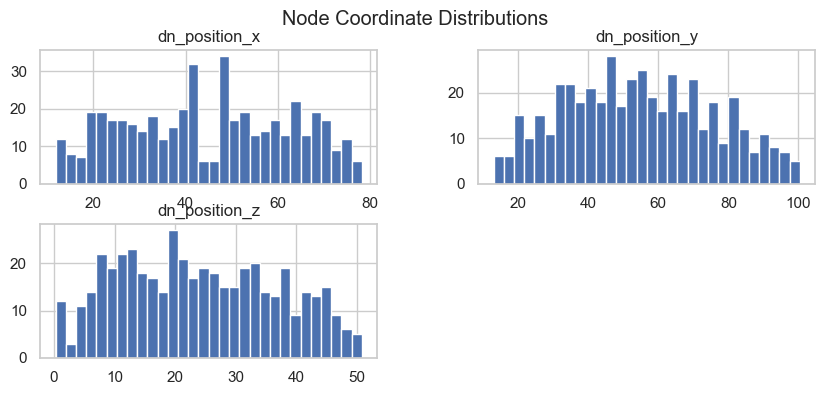

In [29]:
nodes_df[["dn_position_x", "dn_position_y", "dn_position_z"]].hist(bins=30, figsize=(10, 4))
plt.suptitle("Node Coordinate Distributions")
plt.show()

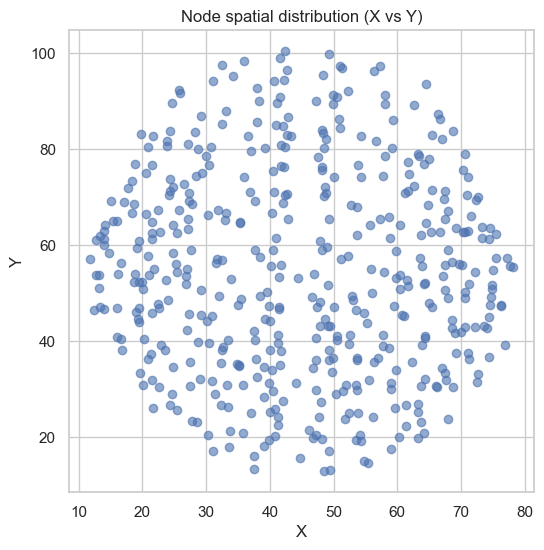

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(nodes_df["dn_position_x"], nodes_df["dn_position_y"], alpha=0.6)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Node spatial distribution (X vs Y)")
plt.show()

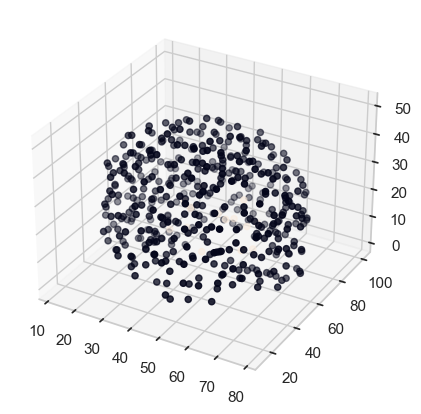

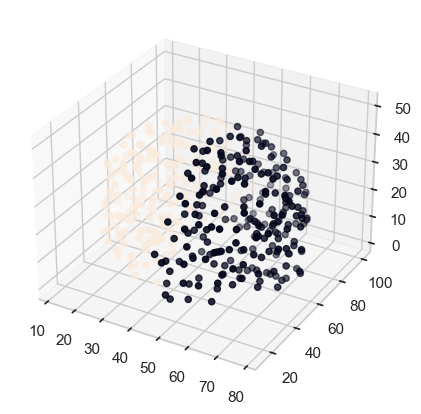

In [31]:
def plot_3d(df, x="dn_position_x", y="dn_position_y", z="dn_position_z", color_by=None):
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection="3d")

    if color_by is None:
        ax.scatter(df[x], df[y], df[z])
    else:
        s = df[color_by]

        if is_numeric_dtype(s):
            sc = ax.scatter(df[x], df[y], df[z], c=s)
            fig.colorbar(sc, ax=ax)
        else:
            categories = pd.Categorical(s)
            ax.scatter(df[x], df[y], df[z], c=categories.codes)

    plt.show()


plot_3d(nodes_df, color_by="dn_region")
plot_3d(nodes_df, color_by="dn_hemisphere")

In [32]:
display(edges_df.describe())

,fiber_length_mean,FA_mean,number_of_fibers
count,5863.000000,5863.000000,5863.000000
mean,32.102900,0.253511,99.983818
std,16.611746,0.095974,236.337483
min,10.466734,0.071174,1.125000
25%,17.455133,0.181884,7.062500
50%,28.837954,0.233154,21.625000
75%,42.828510,0.307814,84.500000
max,101.464587,0.732488,4630.625000


In [33]:
display(edges_df.describe())

,fiber_length_mean,FA_mean,number_of_fibers
count,5863.000000,5863.000000,5863.000000
mean,32.102900,0.253511,99.983818
std,16.611746,0.095974,236.337483
min,10.466734,0.071174,1.125000
25%,17.455133,0.181884,7.062500
50%,28.837954,0.233154,21.625000
75%,42.828510,0.307814,84.500000
max,101.464587,0.732488,4630.625000


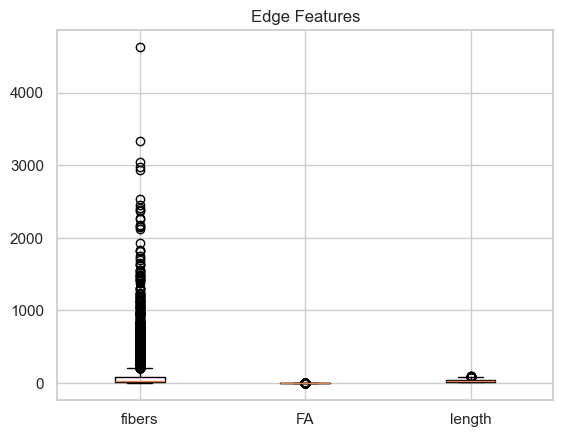

In [34]:
plt.boxplot([
    edges_df["number_of_fibers"].dropna(),
    edges_df["FA_mean"].dropna(),
    edges_df["fiber_length_mean"].dropna()
])
plt.xticks([1,2,3], ["fibers", "FA", "length"])
plt.title("Edge Features")
plt.show()

In [35]:
def spearman_corr_matrix(df, cols):
    return df[cols].corr(method="spearman")

cols = ["fiber_length_mean", "FA_mean", "number_of_fibers"]

corr = spearman_corr_matrix(edges_df, cols)
display(corr)

,fiber_length_mean,FA_mean,number_of_fibers
fiber_length_mean,1.000000,0.080871,-0.374497
FA_mean,0.080871,1.000000,0.042448
number_of_fibers,-0.374497,0.042448,1.000000


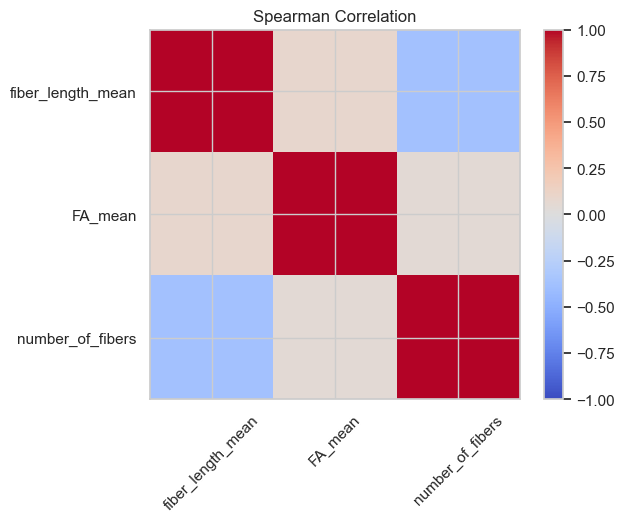

In [36]:
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.title("Spearman Correlation")
plt.show()

In [37]:
edges_df.sort_values("number_of_fibers", ascending=False).head()

,file,path,source,target,fiber_length_mean,FA_mean,number_of_fibers
2985,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,224,456,27.854244,0.453436,4630.625
2989,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,225,226,18.243837,0.142050,3329.250
4151,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,315,456,14.239952,0.450401,3041.625
4655,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,343,449,25.284090,0.356089,2970.750
1301,100206_repeated10_scale250.graphml,..\data\repeated_10_scale_250\100206_repeated1...,87,225,16.299284,0.411054,2931.125


In [38]:
print("SUMMARY:")
print("- Graph has", G.number_of_nodes(), "nodes and", G.number_of_edges(), "edges")
print("- Nodes represent brain regions")
print("- Edges represent connections between regions")
print("- Edge features show variability and some strong connections")

SUMMARY:
- Graph has 463 nodes and 5863 edges
- Nodes represent brain regions
- Edges represent connections between regions
- Edge features show variability and some strong connections
